# March Madness (Basketball) Prediction with Machine Learning

This notebook showcases my submission to the [2026 March Madness Kaggle competition](https://www.kaggle.com/competitions/march-machine-learning-mania-2026/overview). March Madness is a basketball tournament featuring the top U.S. college teams. Sixty-four teams compete in a single-game elimination tournament broken into four rounds. It has long been a tradition in the U.S., whether basketball fan or not, to pick winners and losers and to fill out a March Madness bracket. 

The Kaggle competition approaches this game within a game as an opportunity to harness historical data and machine learning models. I focussed on feature engineering, feature selection, and model optimization. My code is organized into modules to be imported below. The repo can be found at [https://github.com/ian-null-null/march_madness](https://github.com/ian-null-null/march_madness).

Processing mens tournament...
Skipping Optuna, using frozen mens Elo params
Skipping Optuna, using frozen mens XGBoost params

Validation results:


100%|██████████| 22/22 [00:11<00:00,  1.92it/s]


Processing womens tournament...
Skipping Optuna, using frozen womens Elo params
Skipping Optuna, using frozen womens XGBoost params

Validation results:


100%|██████████| 15/15 [00:06<00:00,  2.29it/s]


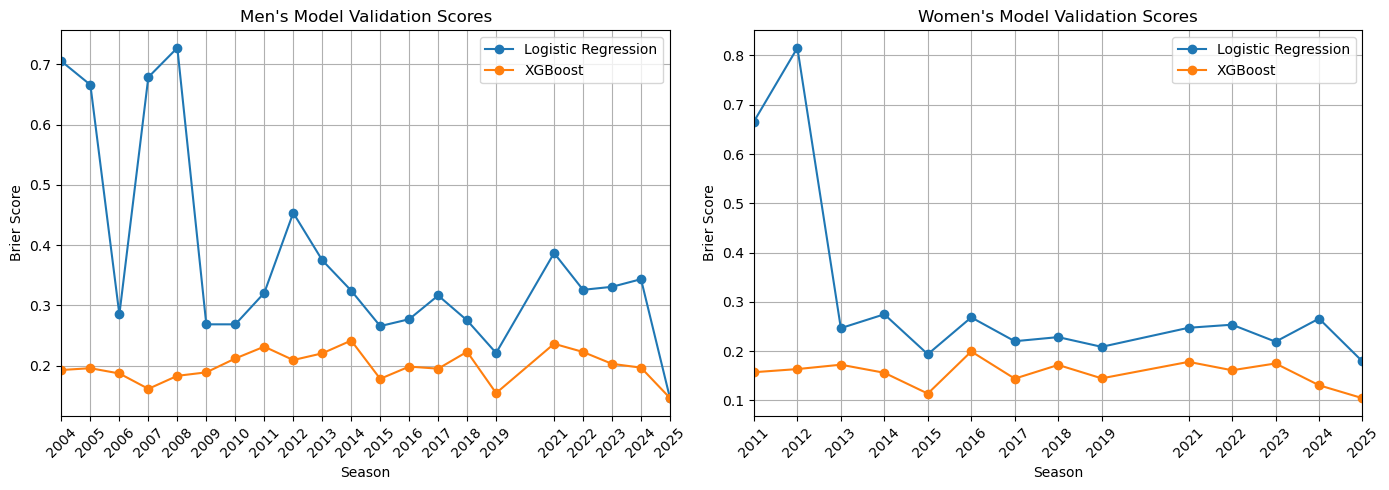

In [1]:
#%%
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats

from madness import (
    DataLoader,
    DataPaths,
    EloConfig,
    EloSystem,
    FeatureEngineer,
    ModelConfig,
    ModelTrainer,
    PredictionEngine,
    TournamentPredictor,
    TrainingConfig,
)
from madness.debug_tools import inspect_decision_matrix

__all__ = [
    "DataLoader",
    "DataPaths",
    "EloConfig",
    "EloSystem",
    "FeatureEngineer",
    "ModelConfig",
    "ModelTrainer",
    "PredictionEngine",
    "TournamentPredictor",
    "TrainingConfig",
    "inspect_decision_matrix",
]


if __name__ == "__main__":
    np.random.seed(9001)
    predictor = TournamentPredictor()
    mens_model, mens_reg_seasons, mens_validation_results, mens_impactful_features \
        = predictor.train_gender(
            "mens",
            optimize_elo=False,
            optimize_xgb=False,
            return_diagnostics=True,

    )

    womens_model, womens_reg_seasons, womens_validation_results, womens_impactful_features \
        = predictor.train_gender(
            "womens",
            optimize_elo=False,
            optimize_xgb=False,
            return_diagnostics=True,

    )
mens_validation_results_df = pd.DataFrame(mens_validation_results).transpose()
womens_validation_results_df = pd.DataFrame(womens_validation_results).transpose()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

years_mens = mens_validation_results_df.index.astype(int)
ax1.plot(years_mens, mens_validation_results_df["logit_brier"],'-o')
ax1.plot(years_mens, mens_validation_results_df["xgb_brier"], '-o')
ax1.legend(["Logistic Regression", "XGBoost"])
ax1.set_xlabel("Season")
ax1.set_ylabel("Brier Score")
ax1.set_xlim(2004, 2025)
ax1.set_xticks(years_mens)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)
ax1.set_title("Men's Model Validation Scores")

years_womens = womens_validation_results_df.index.astype(int)
ax2.plot(years_womens, womens_validation_results_df["logit_brier"], '-o')
ax2.plot(years_womens, womens_validation_results_df["xgb_brier"], '-o')
ax2.legend(["Logistic Regression", "XGBoost"])
ax2.set_xlabel("Season")
ax2.set_ylabel("Brier Score")
ax2.set_xlim(2011, 2025)
ax2.set_xticks(years_womens)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)
ax2.set_title("Women's Model Validation Scores")

plt.tight_layout()
plt.show()

### Modeling

Two models were tested: logistic regression and XGBoost. The chart above shows the rolling validation error of the two models for both tournaments. Moving right along the x-axis corresponds to increasing years of training data. For example, the point at 2004 for the men's tournament was only trained on data from 2003 but the point at 2015 was trained on all the years between 2003 and 2014.

We see a general decrease in the Brier score for the logistic regression model as it is given more and more training data, the XGBoost model, however, does not have such a drastic improvement and in fact performs fairly well when trained on only one season. XGBoost was used for all remaining modelling.

ML modeling performance often rests heavily on hyperparameter tuning and for this project I used the package Optuna to find these hyperparameters using optimization. This was my first time using Optuna and I found it very useful by taking some of the trial-and-error out of the modeling tuning process. Not only did I optimize the XGBoost hyperparameters but also the Elo (as discussed below) algorithm's constants were also tuned.

### Features

A significant portion of the project was spent researching, creating, and adjusting model features. [From The Rumble Seat](https://www.fromtherumbleseat.com/pages/advanced-basketball-statistics-formula-sheet) was a useful resource for information on advanced statistics used in basketball such as offensive and defensive derived metrics.

Instead of training the models on the raw features for team A and team B, I created interaction features such as the difference and the ratio between the two teams features. 

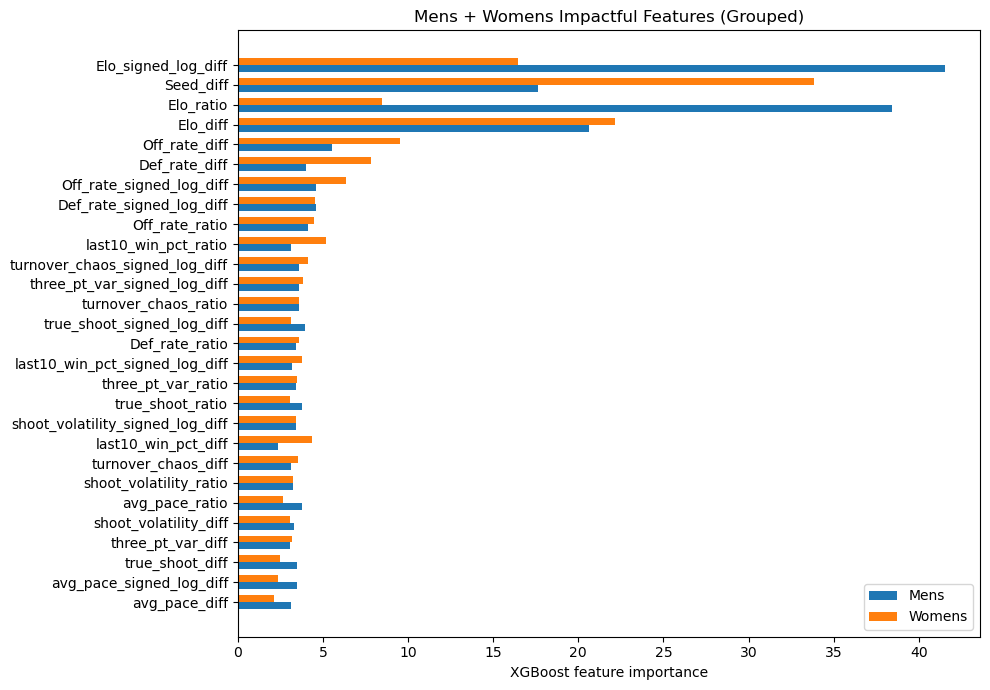

In [2]:
def plot_feature_importance_grouped(
    mens_impactful_features,
    womens_impactful_features,
    title="Mens + Womens Impactful Features (Grouped)",
):
    mens_s = pd.Series(mens_impactful_features, name="Mens")
    womens_s = pd.Series(womens_impactful_features, name="Womens")

    df = pd.concat([mens_s, womens_s], axis=1).fillna(0.0)
    df["total"] = df["Mens"] + df["Womens"]
    df = df.sort_values("total", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(df) * 0.25)))
    
    y_pos = np.arange(len(df))
    bar_height = 0.35
    
    ax.barh(y_pos - bar_height/2, df["Mens"], bar_height, label="Mens")
    ax.barh(y_pos + bar_height/2, df["Womens"], bar_height, label="Womens")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df.index)
    ax.set_xlabel("XGBoost feature importance")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_feature_importance_grouped(mens_impactful_features, womens_impactful_features)

A very common feature found in sports models is some variation of an [Elo rating system](https://en.wikipedia.org/wiki/Elo_rating_system#). Known best for its use in ranking chess players, the Elo system attempts to rate the ability of a team (or player) in a self-correcting manner. For example, if a high Elo rated team beats a low rated team then the high Elo team only gains a few Elo points from the low rated team, but if the high rated team is upset then they lose many points to the low rated team. 

As seen in the above chart the Elo and seed features were the most predictive.

### Predictions

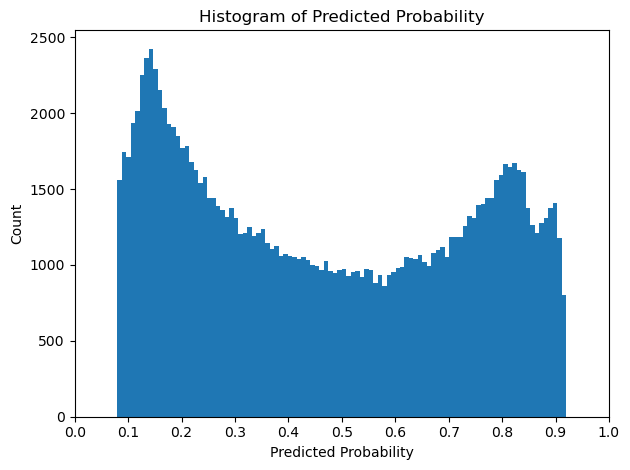

In [3]:
preds = pd.read_csv('data/SubmissionStage2.csv')

plt.hist(preds['Pred'], bins=100)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Histogram of Predicted Probability')
plt.tight_layout()
plt.show()


Model predictions were submitted for every possible team matchup from the 2025/2026 season, not just the 64 tournament teams. Combining both the men's and women's teams results in over 132 thousand predictions.

Looking at the histogram above we can see the predictions follow a 'U' shaped distribution with distinct modes at the two extremes. This tells us that for a given game the model is most likely to strongly favor one team.

This is fairly common with sports analytics or betting where the few teams considered to be the strongest are predicted to almost certainly win; statistically, this is a safe bet. Driving the model to this determination are mainly the Elo and seed features. Historically, in tournament games the higher seed team wins about 70% of the time and understandably the model learns this strong probability. The story is similar to Elo, a 1800 Elo rated team is expected to beat a 1600 rated team 76% of the time. 

This presents a challenge, the model misses upsets. Every year out of the 128 games there's always a few games that surprise or even shock, but can we predict which ones? Probably not very well, in my opinion, but there are some things we can do.

One thing that I did was to bias the generated predictions to encourage more upsets.

$$P_{new} = P + (0.5 - P) \times \lambda$$

The above adjustment pulls extreme predictions $P$ toward the middle, the extent to which is controlled by $\lambda$. The result of this adjustment can be seen on the histogram as all prediction values are squeezed between ~ 0.08 and 0.92. 

### Takeaways and Future Expansion

This was a fun project and one where I could use my skills and learn some new things too. Although I have experience with boosted ensemble learners, this was the first time working with the XGBoost package specifically, but along with Optuna probably won't be my last.


If I partake in next year's challenge there will certainly be no shortage of new things to try. Here are only a few that I've considered:

- Test the other leading ensemble learners: LightGBM and CatBoost
- Test TabPFN: A neural net optimized for tabular data
- Implement Monte Carlo bracket simulation
- Further improve upset prediction:
    - Create a second model solely to predict upset probabilities
    - Shrink seed impact
    - Bias regular season upset features

*Development was completed locally in VSCode using Copilot for refactoring and Supermaven for line autocompletion*